In [3]:
#Import all the required packages for our code

import pandas as pd #for data frame functions
import numpy as np #for mathematical functions
import os, math, sys, pickle #for OS, basic math, system libraries, pickle to save and load models
import matplotlib.pyplot as plt #for plotting diagrams
import seaborn as sns #for plotting figures
from sklearn.model_selection import train_test_split #for test-train splitting function
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score #for metrics calculations
from sklearn import preprocessing #for MinMaxScaler and Label Encoder
import tensorflow as tf #for Neural Networks
import keras #for Neural Networks
from keras.layers import Dense, Dropout #for Neural Networks layers
from keras.models import Sequential, load_model #for Neural Networks model type and saving and loading model
from datetime import datetime as dt #for calculating time elapsed while training a model
from sklearn.linear_model import LogisticRegression #for Logistic Regression Model
from sklearn.tree import DecisionTreeClassifier #for Decision Tree Classifier
from sklearn import svm #for Support Vector Classifier

In [4]:
#Balance dataset, remove Timestamp column and 'Label' values in Label column

def Modify(df):
    #Drop NA values
    df.dropna(inplace=True)
    #Drop Duplicate values
    df.drop_duplicates(inplace=True) 
    #Upon careful inspection of the datasets, few attribute values in a few records were found to be same as the attribute/column names
    df = df[df['Label']!='Label']
    #Split dataset in order to balance all label values as attacks or not throughout the database
    df1 = df[df['Label']!='Benign']
    df1['Label']='Harmful'
    df0 = df[df['Label']=='Benign'][:len(df1)]
    df = pd.concat([df0,df1])
    #Removing the timestamp column as it was a string and appeared irrelevant to our use and also caused a few errors in our code because of its datatype
    df.drop(['Timestamp'], axis=1, inplace=True)
    #Shuffling the preprocessed dataframe and returning it
    print(df['Label'].value_counts())
    return df.sample(frac=1)

In [5]:
def Encode(df):
    #Instantiate an object of the Label Encoder from the preprocessing module of the sklearn package
    le = preprocessing.LabelEncoder()
    #Using the fit_transform() method to encode the labels of our dataset
    df['Label'] = le.fit_transform(df['Label'])
    #Print value counts of the encoded labels in the dataframe
    print(df['Label'].value_counts())
    #Return the encoded dataframe
    return df

In [6]:
#Generalise different attacks
#Create a dictionary to classify all attacks according to their type
allAttacks = {'Benign':'Benign',
               'FTP-BruteForce':'BruteForce', 'SSH-Bruteforce':'BruteForce', 'Brute Force -Web':'BruteForce', 'Brute Force -XSS':'BruteForce',
               'DoS attacks-GoldenEye':'DoS', 'DoS attacks-Slowloris':'DoS', 'DoS attacks-Hulk':'DoS', 'DoS attacks-SlowHTTPTest':'DoS',
               'DDoS attacks-LOIC-HTTP':'DDoS', 'DDOS attack-HOIC':'DDoS', 'DDOS attack-LOIC-UDP':'DDoS',
               'Bot':'Bot',
               'SQL Injection':'Other', 'Infilteration':'Other'}

def Simplify(df):
    #Replace the current Label attributes in the dataframe with the respective labels in our dictionary
    df.replace({'Label': allAttacks}, inplace=True)
    #Print value counts of the encoded labels in the dataframe
    print(df['Label'].value_counts())
    #Return the simplified dataframe
    return df

In [7]:
#alloting unique numerical values for benign and different types of attack
#Create a dictionary to assign a numeric number to all attacks according to their type for processing the dataframe
genAttacks = {'Benign':0, 'BruteForce':1, 'DoS':2, 'DDoS':3, 'Bot':4, 'Other':5}

def Targetify(df):
    #Replace the current Label attributes in the dataframe with the respective labels in our dictionary
    df = df.replace({'Label': genAttacks})
    #Print value counts of the encoded labels in the dataframe
    print(df['Label'].value_counts())
    #Return the targetified dataframe
    return df

In [8]:
#clean dataset by removing nan, inf and -inf values and also values greater than maximum value of float64

def CleanDataset(df):
    #Check if all records that do not have attribute values as NAN, infinite or a negative infinite value and store their indices
    indices_to_keep = ~df.isin([np.nan, np.inf, -np.inf]).any(1)
    #Use only the dataset with the above stored indices and keep only if they have a float datatype
    df = df[indices_to_keep].astype(np.float64)
    #Even after that we faced errors because some values exceeded the float range so we use only the records with attribute values inside the float range
    maxfloat = sys.float_info.max
    for column in df.columns:
        df = df[df[column]<maxfloat]
    #Return the cleaned dataframe
    return df

In [119]:
#using feature selection to consider which columns to use for the model

def Correlate(df):
    #Apply the correlation function on the dataframe
    corr = df.corr()
    #Create an array filled of the same length as the 1st dimension of the correlation object 'corr' filled with 'True' as its values
    columns = np.full((corr.shape[0],), True, dtype=bool)
    #Change the values of the respective columns' index in the columns array to 'False' for columns with correlation equal to or more than 0.9
    for i in range(corr.shape[0]):
        for j in range(i+1, corr.shape[0]):
            if corr.iloc[i,j] >= 0.9:
                if columns[j]:
                    columns[j] = False
    #Store the column names of all columns with correlation less than 0.9 to 'selected_columns' array
    selected_columns = df.columns[columns]
    #Return the dataframe with only the selected_columns
    return df[selected_columns]

In [10]:
#function to call all necessary functions one by one

def AllPreProcessing(df):
    #Modify the dataframe
    df = Modify(df)
    #Encode the dataframe
    df = Encode(df)
    #Simplify the dataframe
    #df = Simplify(df)
    #Targetify the dataframe
    #df = Targetify(df)
    #Clean the dataframe
    df = CleanDataset(df)
    #Return the dataframe after all the preprocessing
    return df

In [11]:
#Function to Merge all the dataframes fromthe list of dataframes
def MergeDatasets(dataframes):
    mergedDataframe = pd.concat(dataframes)
    #Return the single newly merged dataframe after shuffling it
    return mergedDataframe.sample(frac=1)

In [12]:
#Scaling the dataset for the deep learning model
def ScaleDataset(dataframe):
    #Store all attributes of the dataframe as features excludingthe target column i.e. 'Label'
    features = dataframe.columns[:-1]
    #Store the dataframe with only the features in the variable 'X'
    X = dataframe[features]
    #Convert the data type of all the attribute values to a numeric datatype and use the errors parater as 'coerce' so values for all the invalid parsing will be saved as 'NaN'
    X = X.apply(pd.to_numeric, errors='coerce', axis=1)
    #Fill all NA values with '0'
    X.fillna(0)
    #Drop all records with any NA attribute values generated due to the previous step
    X.dropna(inplace=True)
    #Store the target attribute of the dataframe in the variable 'y'
    y = dataframe['Label']
    
    #Use MinMaxScaler from the preprocessing module of the sklearn package to scale all attribute values in our dataframe
    min_max_scaler = preprocessing.MinMaxScaler()
    #Use the fit_transform() function of the MinMaxScaler by passing all the values of features in our dataframe 'X' and store it in 'x_scaled' variable
    x_scaled = min_max_scaler.fit_transform(X.values)
    #Storing the scaled values with their respective feature columns in a dataframe
    X = pd.DataFrame(x_scaled,columns=features)
    #Return the scaled X and y for further processes
    return X, y

In [13]:
#Function for splitting the dataframe

def SplitDataset(X, y):
    #Split the dataframe in 3 parts as 60:20:20 for training, validation and testing purposes
    X_train, X2, y_train, y2 = train_test_split(X, y, test_size=0.4, random_state=123)
    X_valid, X_test, y_valid, y_test = train_test_split(X2, y2, test_size=0.5, random_state=123)
    
    #Converting the dataframes to numpy arrays for use in training, validation and testing purposes for our Machine Learning Models
    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train)
    X_valid = np.asarray(X_valid)
    y_valid = np.asarray(y_valid)
    X_test = np.asarray(X_test)
    y_test = np.asarray(y_test)
    #Return the training, validation and testing pairs of X and y respectively
    return X_train, y_train, X_valid, X_test, y_valid, y_test

In [14]:
#The prediction by the feedforward neural network is in a numpy array of 2, one for benign attacks and the other for actually harmful attacks
#This function answers if the probability for the attack to be benign or to be harmful is more

def Solution(list1):
    list2 = np.zeros(len(list1))
    for i in range(len(list1)):
        list2[i] = list1[i].argmax()
    return list2

Loading all the 10 data files in individual data frames and displaying their shape.

In [15]:
df1 = pd.read_csv('02-14-2018.csv')
df1.shape

(1048575, 80)

In [16]:
df2 = pd.read_csv('02-15-2018.csv')
df2.shape

(1048575, 80)

In [17]:
df3 = pd.read_csv('02-16-2018.csv')
df3.shape

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3457: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


(1048575, 80)

In [18]:
df4 = pd.read_csv('02-20-2018.csv')
df4.shape

(7948748, 84)

In [213]:
#Note: Shape of the 4th data frame, df4, is a little different in terms of the columns.

In [19]:
df5 = pd.read_csv('02-21-2018.csv')
df5.shape

(1048575, 80)

In [20]:
df6 = pd.read_csv('02-22-2018.csv')
df6.shape

(1048575, 80)

In [21]:
df7 = pd.read_csv('02-23-2018.csv')
df7.shape

(1048575, 80)

In [22]:
df8 = pd.read_csv('02-28-2018.csv')
df8.shape

(613104, 80)

In [23]:
df9 = pd.read_csv('03-01-2018.csv')
df9.shape

(331125, 80)

In [24]:
df10 = pd.read_csv('03-02-2018.csv')
df10.shape

(1048575, 80)

Try to find the extra columns in df4 by comparing it with df1

In [25]:
df1.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [26]:
df4.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE 

Dropping the extra columns from df4

In [27]:
df4 = df4.drop(['Flow ID', 'Src IP', 'Src Port', 'Dst IP'], axis=1)

In [28]:
df4.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,6,20/02/2018 08:34:07,888751,11,11,1249.0,1969.0,736.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
1,0,0,20/02/2018 08:33:22,112642816,3,0,0.0,0.0,0.0,0.0,...,0,0.0,0.0,0.0,0.0,56300000.0,7.071068,56300000.0,56300000.0,Benign
2,0,0,20/02/2018 08:36:11,112642712,3,0,0.0,0.0,0.0,0.0,...,0,0.0,0.0,0.0,0.0,56300000.0,18.384776,56300000.0,56300000.0,Benign
3,0,0,20/02/2018 08:39:00,112642648,3,0,0.0,0.0,0.0,0.0,...,0,0.0,0.0,0.0,0.0,56300000.0,5.656854,56300000.0,56300000.0,Benign
4,0,0,20/02/2018 08:41:49,112642702,3,0,0.0,0.0,0.0,0.0,...,0,0.0,0.0,0.0,0.0,56300000.0,65.053824,56300000.0,56300000.0,Benign


Appling pre-processing on all 10 data frames

In [29]:
df1 = AllPreProcessing(df1)

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


Benign     156668
Harmful    156668
Name: Label, dtype: int64
1    156668
0    156668
Name: Label, dtype: int64


In [30]:
df2 = AllPreProcessing(df2)

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


Benign     51740
Harmful    51740
Name: Label, dtype: int64
0    51740
1    51740
Name: Label, dtype: int64


In [31]:
df3 = AllPreProcessing(df3)

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


Harmful    455975
Benign     446752
Name: Label, dtype: int64
1    455975
0    446752
Name: Label, dtype: int64


In [32]:
df4 = AllPreProcessing(df4)

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


Benign     576175
Harmful    576175
Name: Label, dtype: int64
1    576175
0    576175
Name: Label, dtype: int64


In [33]:
df5 = AllPreProcessing(df5)

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


Harmful    670191
Benign     360827
Name: Label, dtype: int64
1    670191
0    360827
Name: Label, dtype: int64


In [34]:
df6 = AllPreProcessing(df6)

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


Benign     362
Harmful    362
Name: Label, dtype: int64
1    362
0    362
Name: Label, dtype: int64


In [35]:
df7 = AllPreProcessing(df7)

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


Benign     566
Harmful    566
Name: Label, dtype: int64
1    566
0    566
Name: Label, dtype: int64


In [36]:
df8 = AllPreProcessing(df8)

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


Benign     68449
Harmful    68449
Name: Label, dtype: int64
0    68449
1    68449
Name: Label, dtype: int64


In [37]:
df9 = AllPreProcessing(df9)

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


Benign     92611
Harmful    92611
Name: Label, dtype: int64
0    92611
1    92611
Name: Label, dtype: int64


In [38]:
df10 = AllPreProcessing(df10)

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


Benign     282310
Harmful    282310
Name: Label, dtype: int64
0    282310
1    282310
Name: Label, dtype: int64


Make a list of all 10 data frames to merge them all together

In [53]:
allDF = [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10]

In [54]:
mainDf = MergeDatasets(allDF)

Apply CORRELATION function on the merged data frame of all 10 individual data frames

In [58]:
mainDf = Correlate(mainDf)

In [59]:
mainDf.shape

(4388088, 47)

In [43]:
#Display all the columns in use for training models with correlation less than 0.9
mainDf.columns

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Bwd Pkt Len Max',
       'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Bwd Pkts/s', 'Pkt Len Max', 'Pkt Len Var',
       'FIN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt',
       'URG Flag Cnt', 'Down/Up Ratio', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg',
       'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg',
       'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
       'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Idle Min', 'Label'],
      dtype='object')

Apply the Scaling and Splitting function to get the scaled and then split data for model training

In [45]:
X, y = ScaleDataset(mainDf)
X_train, y_train, X_valid, X_test, y_valid, y_test = SplitDataset(X, y)

# MODEL TRAINING

Feed Forward Neural Network Model

In [47]:
#Instantiate and Compile the model with the respective parameters

FFNNModel = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(2, activation='softmax')
])

FFNNModel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [48]:
#Calculating the time when model training starts
FFNNStart = dt.now()
#Train the model with the respective parameters and validation dataset
FFNNModel.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))
#Calculating the time when model training ends
FFNNSecs = (dt.now() - FFNNStart).seconds

2022-08-21 18:28:17.877006: I tensorflow/core/platform/cpu_feature_guard.cc:145] This TensorFlow binary is optimized with Intel(R) MKL-DNN to use the following CPU instructions in performance critical operations:  SSE4.1 SSE4.2
To enable them in non-MKL-DNN operations, rebuild TensorFlow with the appropriate compiler flags.
2022-08-21 18:28:17.878719: I tensorflow/core/common_runtime/process_util.cc:115] Creating new thread pool with default inter op setting: 8. Tune using inter_op_parallelism_threads for best performance.


Train on 2632852 samples, validate on 877618 samples
Epoch 1/5
2632852/2632852 [==============================] - 479s 182us/sample - loss: 0.1145 - accuracy: 0.9611 - val_loss: 0.1003 - val_accuracy: 0.9640
Epoch 2/5
2632852/2632852 [==============================] - 478s 182us/sample - loss: 0.1038 - accuracy: 0.9638 - val_loss: 0.0973 - val_accuracy: 0.9660
Epoch 3/5
2632852/2632852 [==============================] - 483s 183us/sample - loss: 0.1026 - accuracy: 0.9643 - val_loss: 0.0993 - val_accuracy: 0.9649
Epoch 4/5
2632852/2632852 [==============================] - 483s 183us/sample - loss: 0.1012 - accuracy: 0.9648 - val_loss: 0.0959 - val_accuracy: 0.9659
Epoch 5/5
2632852/2632852 [==============================] - 480s 182us/sample - loss: 0.1008 - accuracy: 0.9652 - val_loss: 0.0942 - val_accuracy: 0.9668


In [214]:
#Total Time taken for training FFNN Model
print(FFNNSecs)

2404


In [56]:
#Save the FFNN Model.
FFNNModel.save('FinalModels/FFNNModel.h5')

In [60]:
#Predict using the FFNN Model the values for the test dataset X_test
predictions = FFNNModel.predict(X_test)
#Predictions include probability for Benign and Harmful both, so use Solution function to calculate whose probability is higher
exactPredictions = Solution(predictions)

In [62]:
#Calculate the Accuracy for FFNN Model
accuracy_score(y_test, exactPredictions)

0.9663817287247982

In [199]:
#Calculate the F1 Score for FFNN Model
f1_score(y_test, exactPredictions)

0.9677580806965933

In [63]:
#Calculate the Confusion Matrix for FFNN Model
confusion_matrix(y_test, exactPredictions)

array([[405325,   1498],
       [ 28006, 442789]])

[Text(0.5, 15.0, 'Predicted Label'), Text(33.0, 0.5, 'True Label')]

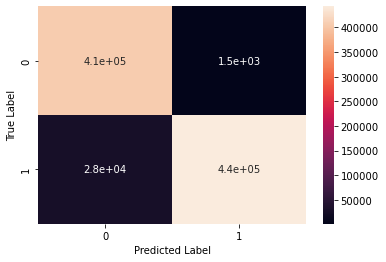

In [212]:
#Plot confusion Matrix for FFNN Model using Seaborn
conf_m = sns.heatmap(confusion_matrix(y_test, exactPredictions), annot=True)
conf_m.set(xlabel='Predicted Label', ylabel='True Label')

Logistic Regression

In [65]:
#Instantiate the Logistic Regression Model
LRModel = LogisticRegression()
#Calculating the time when model training starts
LRStart = dt.now()
#Train the model with the respective parameters
LRModel.fit(X_train, y_train)
#Calculating the time when model training ends
LRSecs = (dt.now() - LRStart).seconds

/Users/samael/opt/anaconda3/envs/tf/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


In [66]:
#Total Time taken for training Logistic Regression(LR) Model
print(LRSecs)

24


In [67]:
#Save the LR Model
pickle.dump(LRModel, open('FinalModels/LRModel.sav', 'wb'))

In [68]:
#Predict using the LR Model the values for the test dataset X_test
LRPredictions = LRModel.predict(X_test)
#Calculate the Accuracy for LR Model
accuracy_score(y_test, LRPredictions)

0.9313004063271264

In [200]:
#Calculate the F1 Score for LR Model
f1_score(y_test, LRPredictions)

0.9363609687926823

In [69]:
#Calculate the Confusion Matrix for LR Model
confusion_matrix(y_test, LRPredictions)

array([[373769,  33054],
       [ 27238, 443557]])

Decision Tree CLassifier

In [71]:
#Instantiate the Decision Tree Classifier (DT) Model
DTModel = DecisionTreeClassifier()
#Calculating the time when model training starts
DTStart = dt.now()
#Train the model with the respective parameters
DTModel.fit(X_train, y_train)
#Calculating the time when model training ends
DTSecs = (dt.now() - DTStart).seconds

In [72]:
#Total Time taken for training DT Model
print(DTSecs)

51


In [73]:
#Save the DT Model
pickle.dump(DTModel, open('FinalModels/DTModel.sav', 'wb'))

In [74]:
#Predict using the DT Model the values for the test dataset X_test
DTPredictions = DTModel.predict(X_test)
#Calculate the Accuracy Score for DT Model
accuracy_score(y_test, DTPredictions)

0.9606127039326905

In [201]:
#Calculate the F1 Score for DT Model
f1_score(y_test, DTPredictions)

0.9630817110981287

In [75]:
#Calculate the Confusion Matrix Score for DT Model
confusion_matrix(y_test, DTPredictions)

array([[392179,  14644],
       [ 19923, 450872]])

Support Vector Classififer

In [4]:
#Instantiate the Support Vector Classifier (SVC) Model
SVCModel = svm.SVC()
#Train the model with the respective parameters
SVCModel.fit(X_train, y_train)

SVC()

In [5]:
#Predict using the SVC Model the values for the test dataset X_test
SVCPredictions = SVCModel.predict(X_test)
#Calculate the SVC Score for DT Model
accuracy_score(y_test, SVCPredictions)

0.9605950200400516

In [6]:
#Calculate the Confusion Matrix Score for DT Model
confusion_matrix(y_test, SVCPredictions)

array([[157375,   5392],
       [  8441, 179839]])

# Exploratory Data Analysis

In [87]:
import seaborn as sns

In [125]:
#Load all the dataframes and then merge them again
allDF = [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10]ß
mainDf = MergeDatasets(allDF)

In [126]:
#Apply coorelation function on the dataframecorr
corr = mainDf.corr()

<AxesSubplot:>

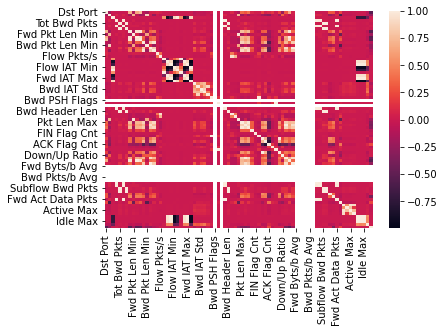

In [91]:
#Plot the heatmap of the correlation function output using Seaborn and use it further accordingly
sns.heatmap(corr)

In [52]:
#WordCloud
#Convert the Label column values and store them into a string of only 10% of the entire dataset for rapid calculation
labels = mainDf['Label'].sample(frac=0.1, random_state=123).values.tolist()
#Instatiate a new empty string
labelStr= ""
#Make labelStr one large string by appending all individual Label attribute values from all records to it for use in WordCloud
for i in range(len(labels)):
    labelStr = labelStr + str(labels[i]) + " "
#Instantiate WordCloud with respective parameters and plpotting through a figure
wordcloud = WordCloud(width = 2000, height = 1000, background_color = 'white')
fig = plt.figure(figsize = (25, 25), facecolor = 'k', edgecolor = 'k')

<Figure size 1800x1800 with 0 Axes>

In [53]:
#Generate the WordCLoud
wordcloud.generate(labelStr)

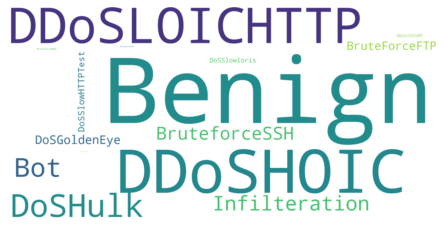

In [54]:
#Display the WordCloud
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()